# Plan
1. Fetch Data
2. Generate All Candidate Features
3. Feature Selection - Pearson filter > Lasso (linear) + XGBoost (nonlinear) + Granger (temporal refinement)
4. Data Preparation - train/val/test split, RobustScaler, sequences (lookback=60)
5. Hyperparameter Tuning - KerasTuner Hyperband
6. Build & Train LSTM
7. MC Dropout Prediction + Conformal Prediction
8. Visualize
9. Evaluate
10. SHAP Explainability


# 0. Configuration

In [1]:
%pip install matplotlib seaborn pandas numpy scipy scikit-learn xgboost statsmodels shap tensorflow yfinance
import yfinance as yf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

%pip install keras-tuner tensorboard -q
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import keras
import shap


In [2]:
stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
stock_data

/tmp/ipykernel_18232/1204826036.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,14.894000,15.425333,14.600000,15.381333,102406500
2016-01-05,14.895333,15.126000,14.666667,15.090667,47802000
2016-01-06,14.602667,14.670000,14.398667,14.666667,56686500
2016-01-07,14.376667,14.562667,14.244667,14.279333,53314500
2016-01-08,14.066667,14.696000,14.051333,14.524000,54421500
...,...,...,...,...,...
2026-06-18,400.489990,402.519989,384.700012,398.100006,58384700
2026-06-22,405.049988,414.750000,394.399994,394.850006,47819500
2026-06-23,381.609985,392.869995,379.059998,392.609985,50420200


# Plan
1. Fetch Data
2. Generate All Candidate Features
3. Feature Selection - Pearson filter > Lasso (linear) + XGBoost (nonlinear) + Granger (temporal, on Lasso+XGBoost)
4. Data Preparation
5. Hyperparameter Tuning
6. Build & Train LSTM
7. MC Dropout + Conformal Prediction
8. Visualize
9. Evaluate
10. SHAP Explainability


In [3]:
df = stock_data.copy()
# --- Technical indicators ---
for w in [5, 10, 20, 50]:
    df[f'EMA_{w}']    = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

df['RSI_14'] = 100 - 100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() /
                             df['Close'].diff().clip(upper=0).abs().rolling(14).mean())

ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']         = ema12 - ema26
df['MACD_signal']  = df['MACD'].ewm(span=9).mean()
df['MACD_hist']    = df['MACD'] - df['MACD_signal']

sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return']   = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']    = df['Close'].pct_change()
df['return_5d']    = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']  = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- More technical features (from research papers) ---
# Volume-based
df['VWAP']           = (df['Close'] * df['Volume']).rolling(20).sum() / df['Volume'].rolling(20).sum()
df['Volume_SMA_20']  = df['Volume'].rolling(20).mean()
df['Volume_Ratio']   = df['Volume'] / df['Volume_SMA_20']
tp = (df['High'] + df['Low'] + df['Close']) / 3
mfr = (tp - df['Low']) - (df['High'] - tp)
df['MFI'] = 100 - 100 / (1 + mfr.rolling(14).sum() / (mfr.abs().rolling(14).sum() + 1e-10))
df['Chaikin_MF'] = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'] + 1e-10)
df['Chaikin_MF'] = (df['Chaikin_MF'] * df['Volume']).rolling(20).sum()

# Volatility
df['Parkinson_Vol'] = np.sqrt(np.log(df['High'] / df['Low']).pow(2).rolling(20).mean() / (4 * np.log(2)))

# Momentum
df['ROC_10']        = df['Close'].pct_change(10)
df['Williams_PctR'] = (df['Close'].rolling(14).max() - df['Close']) / (df['Close'].rolling(14).max() - df['Close'].rolling(14).min() + 1e-10) * -100
ema14_for_trix = df['Close'].ewm(span=14).mean()
df['TRIX'] = ema14_for_trix.pct_change()

# Statistical
df['Skew_20']   = df['return_1d'].rolling(20).skew()
df['Kurt_20']   = df['return_1d'].rolling(20).kurt()
df['AutoCorr_10'] = df['return_1d'].rolling(20).apply(lambda x: x.autocorr(lag=10), raw=False)

# Spread
df['high_low_pct'] = (df['High'] - df['Low']) / df['Close']
df['gap']          = df['Open'] - df['Close'].shift(1)

# --- Time features ---
year_days = df.index.is_leap_year * 366 + (~df.index.is_leap_year) * 365
df['sin_year'] = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year'] = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

df['sin_week'] = np.sin(2 * np.pi * (df.index.isocalendar().week - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (df.index.isocalendar().week - 1) / 52)

df['sin_month'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['cos_month'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

df['is_month_end']   = df.index.is_month_end.astype(int)
df['is_quarter_end'] = df.index.is_quarter_end.astype(int)

# Linear trend feature
df = df.reset_index()
df['days_since_start'] = (df['Date'] - df['Date'].iloc[0]).dt.days.astype(float)

# --- Target ---
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()
df = df.drop(columns=['Date'])

feature_cols = [c for c in df.columns if c not in ['Close_nxt']]
target_col = ['Close_nxt']
print(f'{len(feature_cols)} candidate features:\n{feature_cols}')


53 candidate features:
['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_5', 'Volatility_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'VWAP', 'Volume_SMA_20', 'Volume_Ratio', 'MFI', 'Chaikin_MF', 'Parkinson_Vol', 'ROC_10', 'Williams_PctR', 'TRIX', 'Skew_20', 'Kurt_20', 'AutoCorr_10', 'high_low_pct', 'gap', 'sin_year', 'cos_year', 'day_of_week', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'sin_quarter', 'cos_quarter', 'is_month_end', 'is_quarter_end', 'days_since_start']


---
# 3. Feature Selection

In [4]:
'''Sample split and Other Configuration'''
# Prepare data (using only features, not target)
X_temp = df[feature_cols].values
y = df[target_col].values

# Getting a sample of the data
sample_len = int(len(X_temp)*0.5)
X_sample = X_temp[:sample_len]
y_sample = y[:sample_len]
sample_df = df.iloc[:sample_len].copy()

print(X_sample.shape, y_sample.shape)

# Scale features (separate scaler for train/test)
scaler = RobustScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

(1291, 53) (1291, 1)


Before target filter, 53 features: ['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_5', 'Volatility_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'VWAP', 'Volume_SMA_20', 'Volume_Ratio', 'MFI', 'Chaikin_MF', 'Parkinson_Vol', 'ROC_10', 'Williams_PctR', 'TRIX', 'Skew_20', 'Kurt_20', 'AutoCorr_10', 'high_low_pct', 'gap', 'sin_year', 'cos_year', 'day_of_week', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'sin_quarter', 'cos_quarter', 'is_month_end', 'is_quarter_end', 'days_since_start']


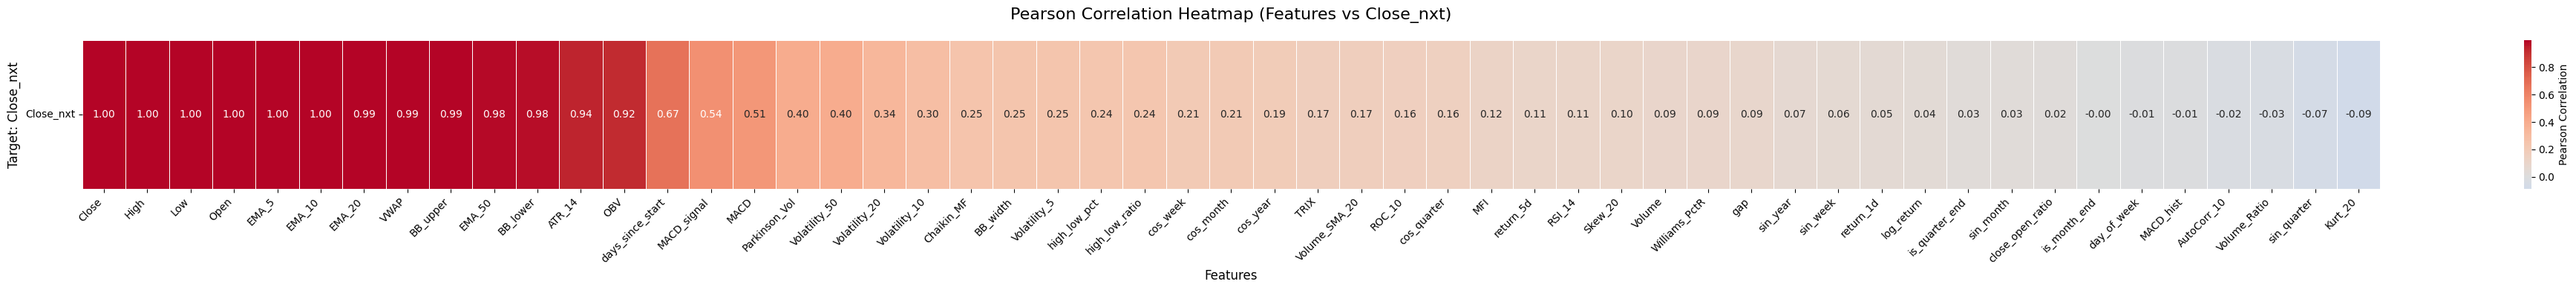

After target filter (>0.25): 21 features
['Close', 'High', 'Low', 'Open', 'EMA_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 'ATR_14', 'OBV', 'VWAP', 'Chaikin_MF', 'Parkinson_Vol', 'days_since_start']


In [5]:
'''Correlation Map Visualization'''
TARGET_THRESHOLD = 0.25
print(f'Before target filter, {len(feature_cols)} features: {feature_cols}')
corr_matrix = sample_df[feature_cols + ['Close_nxt']].corr(method='pearson')
target_corr = corr_matrix['Close_nxt'].abs()
# Plot
plt.figure(figsize=(40, 4))
corr_matrix_for_display = corr_matrix[target_col].drop(target_col).sort_values(by=target_col[0], ascending=False).transpose()
sns.heatmap(corr_matrix_for_display, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title("Pearson Correlation Heatmap (Features vs Close_nxt)", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Target: Close_nxt", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Create selected_features from correlation filter (matching attempt3.4)
selected_features = [f for f in feature_cols if target_corr[f] > TARGET_THRESHOLD]
print(f"After target filter (>{TARGET_THRESHOLD}): {len(selected_features)} features")

# Update feature cols
feature_cols = selected_features.copy()
print(feature_cols)

In [6]:
'''Unified: Lasso | XGBoost | Granger (temporal refinement)'''
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

tscv = TimeSeriesSplit(n_splits=5)
X_sample = df[feature_cols].values[:sample_len]
y_flat = y_sample.ravel()

# -- Set A: Lasso (linear, sparse) --
selection_counts = np.zeros(len(feature_cols), dtype=int)
for train_idx, _ in tscv.split(X_sample):
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_sample[train_idx], y_flat[train_idx])
    selection_counts += (lasso.coef_ != 0).astype(int)
set_A = {feature_cols[i] for i, keep in enumerate(selection_counts >= (5 * 2/3)) if keep}

# -- Set B: XGBoost (nonlinear) --
xgb = XGBRegressor(n_estimators=200, max_depth=5, random_state=42, verbosity=0)
xgb.fit(X_sample, y_flat)
imp = xgb.feature_importances_
thresh = np.percentile(imp, 75)
set_B = {feature_cols[i] for i in range(len(feature_cols)) if imp[i] >= thresh}

# -- Set C: Granger (temporal refinement, only on A|B) --
skip_cols = {'Close', 'High', 'Low', 'Open', 'Volume', 'BB_upper', 'BB_lower',
             'OBV', 'days_since_start', 'EMA_5', 'EMA_10', 'EMA_20', 'EMA_50'}
candidates = [c for c in (set_A | set_B) if c not in skip_cols]
set_C = set()
warnings.filterwarnings('ignore', category=FutureWarning)
for col in candidates:
    temp = pd.DataFrame({'target': y_flat[:len(sample_df)],
                         'feature': sample_df[col].values[:len(sample_df)]}).dropna()
    if len(temp) > 50:
        try:
            result = grangercausalitytests(temp[['target', 'feature']], maxlag=5, verbose=False)
            pvals = [result[lag][0]['ssr_ftest'][1] for lag in range(1, 6)]
            if any(p < 0.05 for p in pvals):
                set_C.add(col)
        except:
            pass
warnings.resetwarnings()

# -- Final Union --
final_features = list(set_A | set_B | set_C)

print(f' Lasso (A): {len(set_A)} features -> {sorted(set_A)}')
print(f' XGBoost (B): {len(set_B)} features -> {sorted(set_B)}')
print(f' Granger on A|B (C): {len(set_C)} features -> {sorted(set_C)}')

selected_features = final_features
feature_cols = final_features
print(f' Final union: {len(feature_cols)} features -> {sorted(feature_cols)}')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.975e+02, tolerance: 1.140e+01
  model = cd_fast.enet_coordinate_descent(


 Lasso (A): 6 features -> ['BB_lower', 'BB_upper', 'Chaikin_MF', 'Close', 'OBV', 'days_since_start']
 XGBoost (B): 6 features -> ['Close', 'EMA_20', 'EMA_5', 'EMA_50', 'High', 'Low']
 Granger on A|B (C): 0 features -> []
 Final union: 11 features -> ['BB_lower', 'BB_upper', 'Chaikin_MF', 'Close', 'EMA_20', 'EMA_5', 'EMA_50', 'High', 'Low', 'OBV', 'days_since_start']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
# Greedy Forward Selection - uses actual LSTM validation loss
LOOKBACK_G = 20
EPOCHS_G   = 15
PATIENCE_G = 5

candidates = list(set_A | set_B | set_C)
print(f'Candidates from union: {sorted(candidates)}')
print(f'Total candidates: {len(candidates)}')

split_train_g = int(len(df) * 0.6)
split_val_g   = int(len(df) * 0.8)

y_all = df[target_col].values
target_scaler_g = RobustScaler()
target_scaler_g.fit_transform(y_all[:split_train_g])

def quick_lstm_loss(feature_list):
    scaler_g = RobustScaler()
    X_tr  = scaler_g.fit_transform(df[feature_list].values[:split_train_g])
    X_val = scaler_g.transform(df[feature_list].values[split_train_g:split_val_g])
    y_tr  = target_scaler_g.transform(y_all[:split_train_g]).ravel()
    y_val = target_scaler_g.transform(y_all[split_train_g:split_val_g]).ravel()

    def mk_seq(X, y, lb):
        Xs, ys = [], []
        for t in range(lb, len(X)):
            Xs.append(X[t-lb:t])
            ys.append(y[t])
        return np.array(Xs), np.array(ys)

    X_tr_s, y_tr_s   = mk_seq(X_tr,  y_tr,  LOOKBACK_G)
    X_val_pad = np.concatenate([X_tr[-LOOKBACK_G:], X_val])
    y_val_pad = np.concatenate([y_tr[-LOOKBACK_G:],  y_val])
    X_val_s, y_val_s = mk_seq(X_val_pad, y_val_pad, LOOKBACK_G)

    m = Sequential([
        Input(shape=(LOOKBACK_G, len(feature_list))),
        LSTM(64),
        Dropout(0.1),
        Dense(1)
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    m.fit(X_tr_s, y_tr_s,
           epochs=EPOCHS_G,
           batch_size=64,
           validation_data=(X_val_s, y_val_s),
           callbacks=[EarlyStopping(monitor='val_loss', patience=PATIENCE_G,
                                     restore_best_weights=True)],
           verbose=0)
    loss_val = m.evaluate(X_val_s, y_val_s, verbose=0)
    return loss_val if isinstance(loss_val, (int, float)) else loss_val[0]

# Sort by XGBoost importance
imp_dict = {c: imp[list(feature_cols).index(c)] if c in feature_cols else 0 for c in candidates}
candidates_sorted = sorted(candidates, key=lambda c: imp_dict[c], reverse=True)

# Greedy forward search
selected = []
remaining = list(candidates_sorted)
best_score = float('inf')
print('\n--- Greedy Forward Selection ---')

for rnd in range(len(remaining)):
    best_feat = None
    best_new_score = best_score
    for feat in remaining[:]:
        try:
            s = quick_lstm_loss(selected + [feat])
            if s < best_new_score:
                best_new_score = s
                best_feat = feat
        except Exception as e:
            print(f'  skip {feat}: {e}')
            continue
    if best_feat is not None and best_new_score < best_score:
        selected.append(best_feat)
        remaining.remove(best_feat)
        best_score = best_new_score
        print(f'  Round {rnd+1}: +{best_feat}  val_loss={best_score:.6f}  selected={selected}')
    else:
        print(f'  Round {rnd+1}: no improvement (best={best_score:.6f}), stopping.')
        break

print(f'\n=== Greedy selection complete ===')
print(f'Selected {len(selected)} features: {selected}')

selected_features = selected
feature_cols     = selected


Candidates from union: ['BB_lower', 'BB_upper', 'Chaikin_MF', 'Close', 'EMA_20', 'EMA_5', 'EMA_50', 'High', 'Low', 'OBV', 'days_since_start']
Total candidates: 11

--- Greedy Forward Selection ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Round 1: +Close  val_loss=0.013534  selected=['Close']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Round 2: +EMA_5  val_loss=0.012998  selected=['Close', 'EMA_5']


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Round 4: +EMA_50  val_loss=0.010351  selected=['Close', 'EMA_5', 'Low', 'EMA_50']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Round 5: no improvement (best=0.010351), stopping.

=== Greedy selection complete ===
Selected 4 features: ['Close', 'EMA_5', 'Low', 'EMA_50']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

### Train / Val / Test Split

| Split  | Slice                         | Rows              |
|--------|-------------------------------|-------------------|
| Train  | `df[:split_idx_train]`        | 70% of dataset    |
| Val    | `df[split_idx_train:split_idx_val]` | 15% of dataset    |
| Test   | `df[split_idx_val:]`          | 15% of dataset    |


In [8]:
LOOKBACK = 60
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
SEL_EPOCHS = 50
SEL_PATIENCE = 8

feature_cols = selected_features          # from forward selection above

split_idx_train = int(len(df) * TRAIN_RATIO)
split_idx_val = int(len(df) * (TRAIN_RATIO + VAL_RATIO))

train_features_raw = df[feature_cols].values[:split_idx_train]
val_features_raw   = df[feature_cols].values[split_idx_train:split_idx_val]
test_features_raw  = df[feature_cols].values[split_idx_val:]
train_target_raw   = df[target_col].values[:split_idx_train]
val_target_raw     = df[target_col].values[split_idx_train:split_idx_val]
test_target_raw    = df[target_col].values[split_idx_val:]

scaler = RobustScaler()
target_scaler  = RobustScaler()

# Scale train (fit + transform)
train_features = scaler.fit_transform(train_features_raw)
train_target = target_scaler.fit_transform(train_target_raw)
# Scale val and test (transform only - using train's statistics)
val_features = scaler.transform(val_features_raw)
val_target = target_scaler.transform(val_target_raw)
test_features = scaler.transform(test_features_raw)
test_target = target_scaler.transform(test_target_raw)

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {train_features.shape}  Test: {test_features.shape}')

Feature columns (4): ['Close', 'EMA_5', 'Low', 'EMA_50']
Train: (1808, 4)  Test: (388, 4)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)
# For val: need padding from train
val_features_padded = np.concatenate([train_features[-LOOKBACK:], val_features])
val_target_padded = np.concatenate([train_target[-LOOKBACK:], val_target])
X_val, y_val = create_sequences(val_features_padded, val_target_padded, LOOKBACK)
# For test: need padding from val  
test_features_padded = np.concatenate([val_features[-LOOKBACK:], test_features])
test_target_padded = np.concatenate([val_target[-LOOKBACK:], test_target])
X_test, y_test = create_sequences(test_features_padded, test_target_padded, LOOKBACK)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1748, 60, 4)  y_train: (1748,)
X_test : (388, 60, 4)  y_test : (388,)


---
# 5. Building and Training LSTM

In [10]:
# Define model builder for KerasTuner
def build_model(hp):
    model = Sequential([
        Input(shape=(LOOKBACK, X_train.shape[2])),
        LSTM(
            hp.Int('units1', min_value=32, max_value=128, step=32),
            return_sequences=True
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        LSTM(
            hp.Int('units2', min_value=32, max_value=128, step=32),
            return_sequences=False
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[0.001, 0.0005])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Run Hyperband search
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='kt_results',
    project_name='lstm_tuning'
)

# Search with early stopping
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1,
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best Hyperparameters:')
print(f'  units1: {best_hp.get("units1")}')
print(f'  units2: {best_hp.get("units2")}')
print(f'  dropout: {best_hp.get("dropout")}')
print(f'  learning_rate: {best_hp.get("learning_rate")}')

Trial 91 Complete [00h 00m 27s]
val_loss: 0.011052538640797138

Best val_loss So Far: 0.0041527338325977325
Total elapsed time: 01h 45m 48s
Best Hyperparameters:
  units1: 96
  units2: 96
  dropout: 0.1
  learning_rate: 0.001


In [11]:
# Build final model with best hyperparameters
model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(best_hp.get('units1'), return_sequences=True),
    Dropout(best_hp.get('dropout')),
    LSTM(best_hp.get('units2'), return_sequences=False),
    Dropout(best_hp.get('dropout')),
    Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_hp.get('learning_rate')),
    loss='mse',
    metrics=['mae']
)

model.summary()

# Train final model
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 96)         │        38,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 96)             │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,993 (441.38 KB)

 Trainable params: 112,993 (441.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0326 - mae: 0.0871 - val_loss: 0.0132 - val_mae: 0.0896
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0075 - mae: 0.0478 - val_loss: 0.0143 - val_mae: 0.0946
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0070 - mae: 0.0462 - val_loss: 0.0111 - val_mae: 0.0836
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0067 - mae: 0.0452 - val_loss: 0.0099 - val_mae: 0.0787
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0058 - mae: 0.0422 - val_loss: 0.0081 - val_mae: 0.0702
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0054 - mae: 0.0404 - val_loss: 0.0088 - val_mae: 0.0689
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0063 - mae: 0.0444 - val_loss: 0.0073 - val_mae: 0.0623
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0049 - mae: 0.0387 - val_loss: 0.0122 - val_mae: 0.0922
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step -

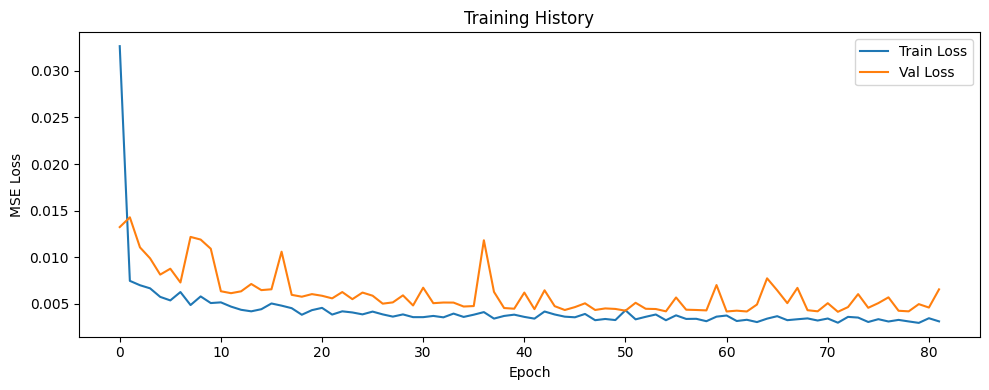

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [13]:
# --- MC Dropout Prediction ---
N_MC = 50  # number of stochastic forward passes
mc_preds = []
for _ in range(N_MC):
    pred = model(X_test, training=True).numpy()  # keep dropout active
    mc_preds.append(pred)
mc_preds = np.array(mc_preds)  # (N_MC, n_samples, 1)

pred_mean = mc_preds.mean(axis=0)
pred_std  = mc_preds.std(axis=0)

prediction = target_scaler.inverse_transform(pred_mean)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# --- Conformal Prediction: calibrate on validation set ---
# Compute MC dropout predictions on validation set
mc_preds_val = []
for _ in range(N_MC):
    pred = model(X_val, training=True).numpy()
    mc_preds_val.append(pred)
mc_preds_val = np.array(mc_preds_val)
pred_mean_val = mc_preds_val.mean(axis=0)

y_val_actual = target_scaler.inverse_transform(y_val.reshape(-1, 1))
pred_val = target_scaler.inverse_transform(pred_mean_val)

# Absolute residuals on calibration (validation) set
abs_resid_val = np.abs(y_val_actual.flatten() - pred_val.flatten())
ALPHA = 0.05  # 95% confidence
q = np.quantile(abs_resid_val, 1 - ALPHA)

# Confidence intervals on test set
ci_lower = prediction.flatten() - q
ci_upper = prediction.flatten() + q

print(f'MC Dropout: {N_MC} passes, pred_mean shape: {prediction.shape}')
print(f'Conformal quantile (95%): {q:.4f}')
print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')


MC Dropout: 50 passes, pred_mean shape: (388, 1)
Conformal quantile (95%): 24.4518
Predictions shape: (388, 1)
Actuals shape     : (388, 1)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
# 7. Visualisation

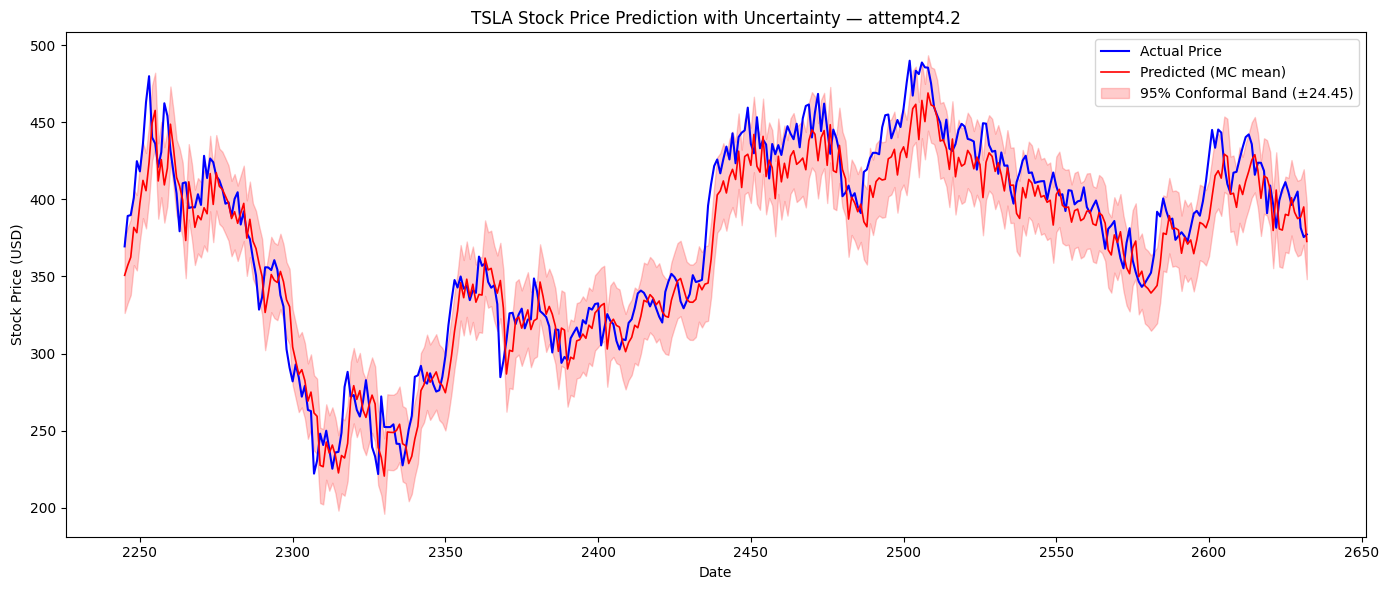

In [14]:
test_dates = df.index[split_idx_val:]     # → 387 rows (85–100% of data)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue', linewidth=1.5)
plt.plot(test_dates, prediction.flatten(), label='Predicted (MC mean)', color='red', linewidth=1.2)
plt.fill_between(test_dates, ci_lower, ci_upper,
                 alpha=0.2, color='red', label=f'95% Conformal Band (±{q:.2f})')
plt.title(f'TSLA Stock Price Prediction with Uncertainty — attempt4.2')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


---
# 8. Model Evaluation

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

# Conformal coverage on test set
covered = (y_test_actual.flatten() >= ci_lower) & (y_test_actual.flatten() <= ci_upper)
coverage = covered.mean() * 100
avg_width = (ci_upper - ci_lower).mean()

print('=' * 55)
print(f'attempt4.2 — LSTM + MC Dropout + Conformal Prediction')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)
print(f'  Conformal coverage (95%): {coverage:.1f}%')
print(f'  Average interval width   : {avg_width:.2f}')
print(f'  Calibration quantile (q) : {q:.4f}')
print('=' * 55)


attempt4.2 — LSTM + MC Dropout + Conformal Prediction
Features: ['Close', 'EMA_5', 'Low', 'EMA_50']
  MSE  : 400.7871
  RMSE : 20.0197
  MAE  : 15.9300
  MAPE : 4.30%
  Conformal coverage (95%): 79.1%
  Average interval width   : 48.90
  Calibration quantile (q) : 24.4518


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


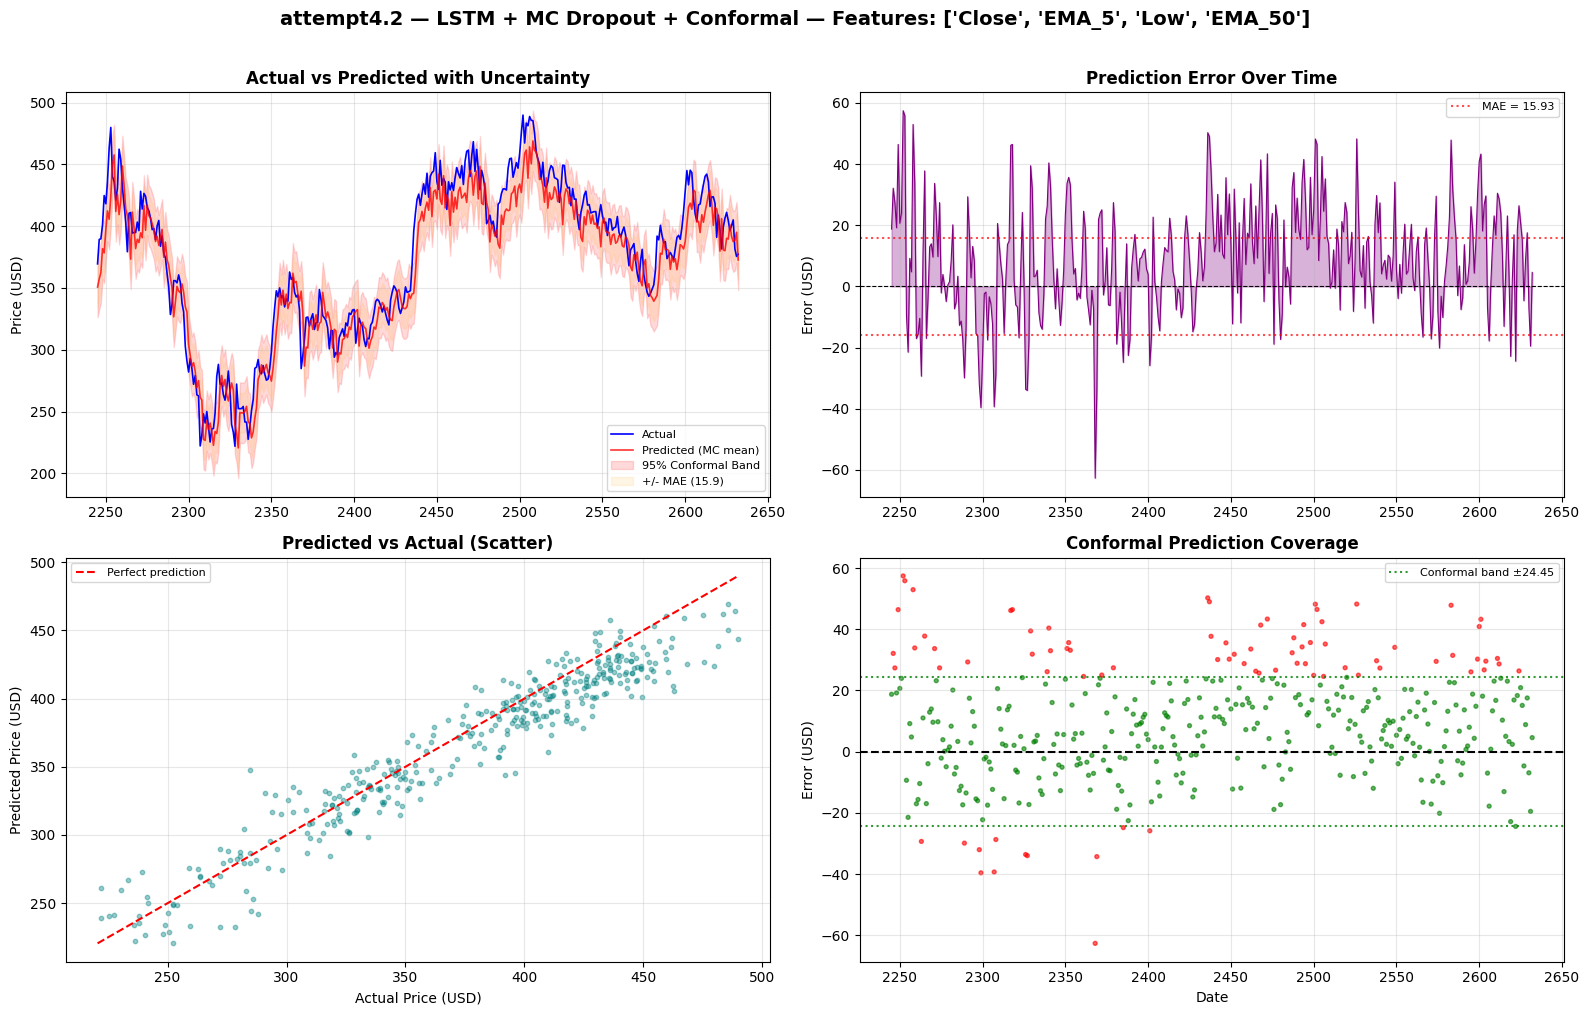

Conformal Coverage (target 95%): 79.1%
Average interval width: 48.90
Mean Error: 8.6377  |  Std Error: 18.0604
Max Over-prediction: 57.4186  |  Max Under-prediction: -62.6582
Mean Abs % Error: 4.30%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
test_dates = df.index[split_idx_val:]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100
covered = (y_test_actual.flatten() >= ci_lower) & (y_test_actual.flatten() <= ci_upper)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted (MC mean)', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, ci_lower, ci_upper,
                alpha=0.15, color='red', label=f'95% Conformal Band')
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.1, color='orange', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted with Uncertainty', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
# Color by whether covered by conformal band
colors = ['green' if c else 'red' for c in covered]
ax.scatter(test_dates, errors, c=colors, s=8, alpha=0.6)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax.axhline(y=q, color='green', linestyle=':', alpha=0.8, label=f'Conformal band ±{q:.2f}')
ax.axhline(y=-q, color='green', linestyle=':', alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Error (USD)')
ax.set_title('Conformal Prediction Coverage', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'attempt4.2 — LSTM + MC Dropout + Conformal — Features: {feature_cols}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Conformal Coverage (target 95%): {coverage:.1f}%')
print(f'Average interval width: {avg_width:.2f}')
print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')


---
# 9. Post-hoc Attention Weight Extraction

Extract attention weights from the first LSTM layer to identify which past timesteps
the model focuses on when making predictions.


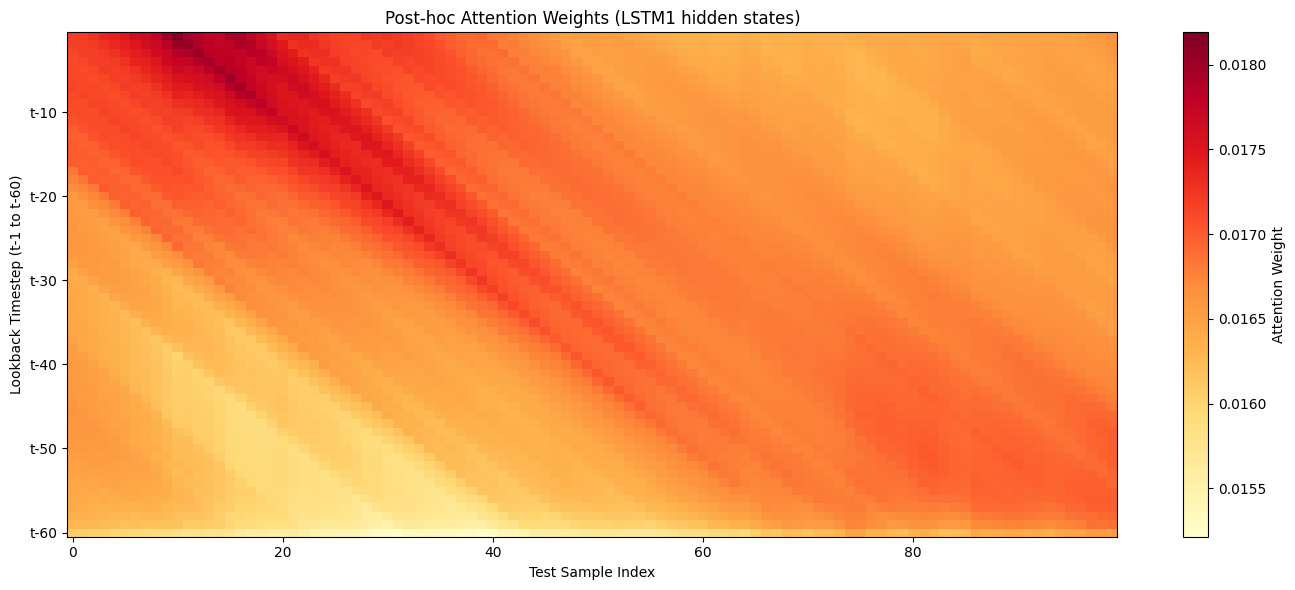

Top-5 most attended lookback positions (averaged across samples):
  1. t-7 (relative importance: 0.0168)
  2. t-8 (relative importance: 0.0168)
  3. t-9 (relative importance: 0.0168)
  4. t-10 (relative importance: 0.0168)
  5. t-6 (relative importance: 0.0168)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
from keras.models import Model

# Build a feature model that outputs 1st LSTM hidden states
lstm1_model = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[0].output  # layer 0 = first LSTM (return_sequences=True)
)

# Get hidden states for a batch of test samples
N_ATTN = min(100, len(X_test))
hidden_states = lstm1_model.predict(X_test[:N_ATTN], verbose=0)  # (N_ATTN, 60, 128)

# Compute dot-product attention: compare each timestep h_t with last timestep h_T
# Attention score = softmax(h_T @ h_t^T) — how much does h_t contribute to h_T?
last_h = hidden_states[:, -1:, :]  # (N_ATTN, 1, 128)
scores = np.matmul(hidden_states, last_h.transpose(0, 2, 1)).squeeze(-1)  # (N_ATTN, 60)
scores = scores / np.sqrt(128)  # scale

# Softmax over timesteps
def softmax(x, axis=-1):
    e_x = np.exp(x - x.max(axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

attention_weights = softmax(scores, axis=-1)  # (N_ATTN, 60)

# --- Visualize attention heatmap ---
plt.figure(figsize=(14, 6))
plt.imshow(attention_weights.T, aspect='auto', cmap='YlOrRd', origin='lower')
plt.colorbar(label='Attention Weight')
plt.xlabel('Test Sample Index')
plt.ylabel('Lookback Timestep (t-1 to t-60)')
plt.title('Post-hoc Attention Weights (LSTM1 hidden states)')
# Add y-tick labels for every 10 timesteps
tick_pos = np.arange(0, 60, 10)
plt.yticks(tick_pos, [f't-{60-i}' for i in tick_pos])
plt.tight_layout()
plt.show()

# --- Show top-5 most attended timesteps across all samples ---
avg_attention = attention_weights.mean(axis=0)
top5_idx = np.argsort(avg_attention)[-5:][::-1]
print("Top-5 most attended lookback positions (averaged across samples):")
for i, idx in enumerate(top5_idx):
    print(f"  {i+1}. t-{60-idx} (relative importance: {avg_attention[idx]:.4f})")


---
# 10. SHAP Explainability


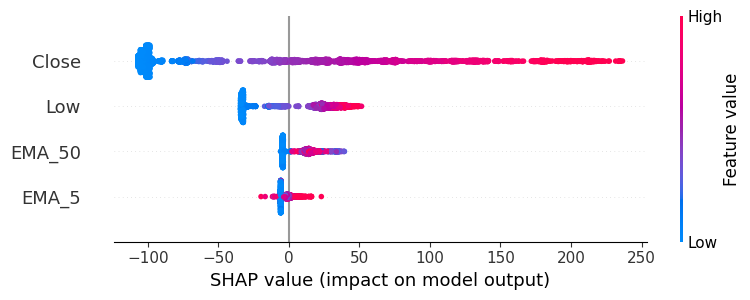

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


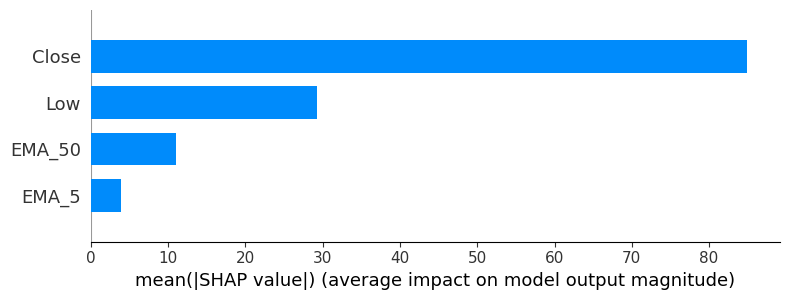

SHAP analysis complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
'''SHAP Explainability - XGBoost Feature Attribution'''
import shap

X_shap = df[feature_cols].values
y_shap = y.ravel()

xgb_shap = XGBRegressor(n_estimators=200, max_depth=5, random_state=42, verbosity=0)
xgb_shap.fit(X_shap, y_shap)

explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

print('SHAP analysis complete.')
